In [1]:
import os
import cv2
import re
import random
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# ============================================
# CELL 2 - PROJECT & OCR DATASET PATHS
# ============================================

PROJECT_DIR = Path.cwd()

OCR_DATASET_DIR = PROJECT_DIR / "plate_ocr"

TRAIN_IMG_DIR = OCR_DATASET_DIR / "images" / "train"
VALID_IMG_DIR = OCR_DATASET_DIR / "images" / "valid"
TEST_IMG_DIR  = OCR_DATASET_DIR / "images" / "test"

TRAIN_LABEL_FILE = OCR_DATASET_DIR / "train_labels.txt"
VALID_LABEL_FILE = OCR_DATASET_DIR / "valid_labels.txt"
TEST_LABEL_FILE  = OCR_DATASET_DIR / "test_labels.txt"

print("Project:", PROJECT_DIR)
print("OCR Dataset:", OCR_DATASET_DIR)

print("\nDataset exists:", OCR_DATASET_DIR.exists())

print("\nTrain images:", TRAIN_IMG_DIR.exists())
print("Valid images:", VALID_IMG_DIR.exists())
print("Test images :", TEST_IMG_DIR.exists())

print("\nTrain labels:", TRAIN_LABEL_FILE.exists())
print("Valid labels:", VALID_LABEL_FILE.exists())
print("Test labels :", TEST_LABEL_FILE.exists())

Project: C:\Users\lenovo\downloads\ANPR_Traffic_AI
OCR Dataset: C:\Users\lenovo\downloads\ANPR_Traffic_AI\plate_ocr

Dataset exists: True

Train images: True
Valid images: True
Test images : True

Train labels: True
Valid labels: True
Test labels : True


In [3]:
# ============================================
# CELL 3 - DATASET COUNTS
# ============================================

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
}

train_images = [
    p for p in TRAIN_IMG_DIR.iterdir()
    if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
]

valid_images = [
    p for p in VALID_IMG_DIR.iterdir()
    if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
]

test_images = [
    p for p in TEST_IMG_DIR.iterdir()
    if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
]

print("========== DATASET SUMMARY ==========")

print("Training images  :", len(train_images))
print("Validation images:", len(valid_images))
print("Test images      :", len(test_images))
print("Total images     :", len(train_images) + len(valid_images) + len(test_images))

========== DATASET SUMMARY ==========
Training images  : 1183
Validation images: 253
Test images      : 254
Total images     : 1690


In [4]:
# ============================================
# CELL 4 - READ GROUND TRUTH LABELS
# ============================================

def read_labels(label_file):

    labels = {}

    with open(label_file, "r", encoding="utf-8") as f:

        for line in f:

            line = line.strip()

            if not line:
                continue

            parts = line.split("\t")

            if len(parts) >= 2:

                image_name = parts[0].strip()
                plate_text = parts[1].strip()

                labels[image_name] = plate_text

    return labels


train_labels = read_labels(TRAIN_LABEL_FILE)
valid_labels = read_labels(VALID_LABEL_FILE)
test_labels = read_labels(TEST_LABEL_FILE)

print("Training labels  :", len(train_labels))
print("Validation labels:", len(valid_labels))
print("Test labels      :", len(test_labels))

Training labels  : 1183
Validation labels: 253
Test labels      : 254


In [5]:
# ============================================
# CELL 5 - CHECK LABELS
# ============================================

print("========== SAMPLE TRAIN LABELS ==========")

for image_name, plate_text in list(train_labels.items())[:10]:

    print(
        image_name,
        "->",
        plate_text
    )

========== SAMPLE TRAIN LABELS ==========
plate_000000.jpg -> MH03CS6266
plate_000001.jpg -> MH02EK0837
plate_000002.jpg -> CG12AG1130
plate_000003.jpg -> DL6CAB123X
plate_000004.jpg -> MH01AR5274
plate_000005.jpg -> MH20EE7597
plate_000006.jpg -> TR07D0569
plate_000007.jpg -> MH02EU4884
plate_000008.jpg -> KA031351
plate_000009.jpg -> HR29AS0015


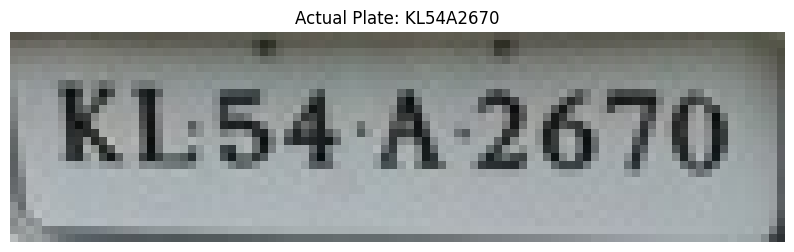

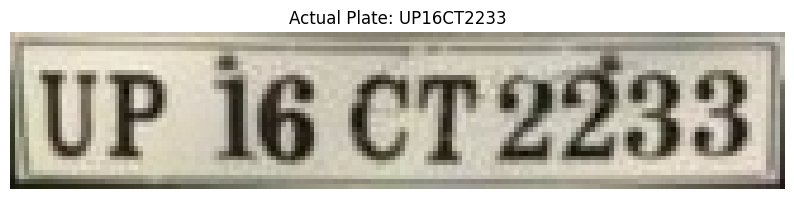

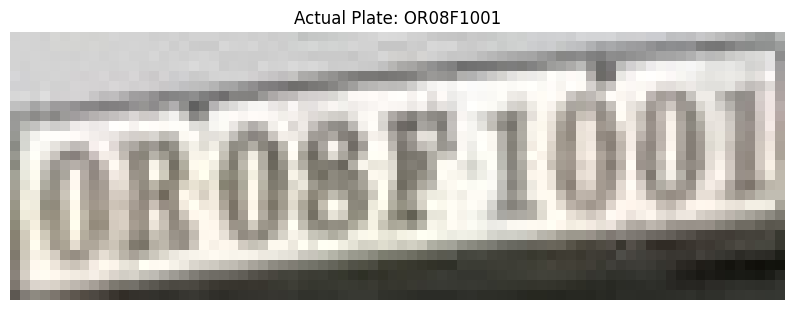

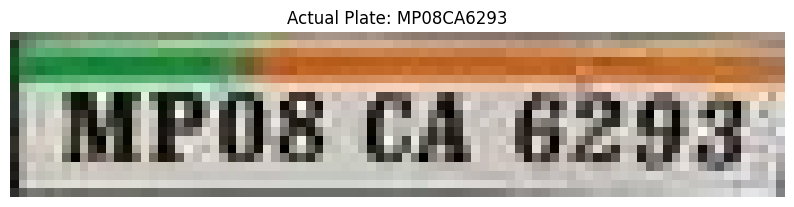

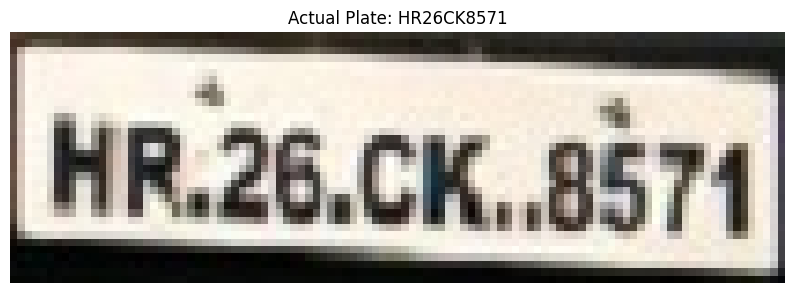

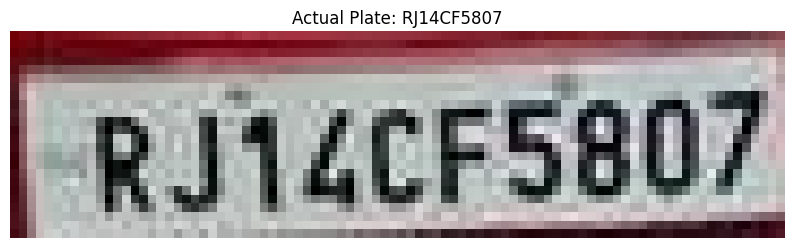

In [6]:
# ============================================
# CELL 6 - VISUALIZE SAMPLE PLATES
# ============================================

sample_names = random.sample(
    list(train_labels.keys()),
    min(6, len(train_labels))
)

for image_name in sample_names:

    image_path = TRAIN_IMG_DIR / image_name

    image = cv2.imread(str(image_path))

    if image is None:
        continue

    image_rgb = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    plt.figure(figsize=(10, 4))

    plt.imshow(image_rgb)

    plt.axis("off")

    plt.title(
        f"Actual Plate: {train_labels[image_name]}"
    )

    plt.show()

In [7]:
import easyocr

print("EasyOCR imported successfully.")

EasyOCR imported successfully.


In [8]:
reader = easyocr.Reader(
    ['en'],
    gpu=False
)

print("EasyOCR model loaded successfully.")

Using CPU. Note: This module is much faster with a GPU.
C:\Users\lenovo\AppData\Roaming\Python\Python313\site-packages\torch\ao\nn\quantized\dynamic\modules\rnn.py:162: UserWarning: torch.quantize_per_tensor, torch.quantize_per_channel and other quantized tensor creation functions that produce tensors with dtype torch.quint8, torch.qint8, and torch.qint32 are deprecated and will be removed in a future PyTorch release. Please see https://github.com/pytorch/pytorch/issues/184982 for more information. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\quantized\Quantizer.cpp:116.)
  w_ih = torch.quantize_per_tensor(


EasyOCR model loaded successfully.


In [9]:
sample_name = list(test_labels.keys())[0]

sample_path = TEST_IMG_DIR / sample_name

print("Image:", sample_name)
print("Actual plate:", test_labels[sample_name])

results = reader.readtext(
    str(sample_path)
)

print("\nOCR OUTPUT:")

for bbox, text, confidence in results:
    print(
        "Text:",
        text,
        "| Confidence:",
        round(confidence, 4)
    )

Image: plate_000000.jpg
Actual plate: TN42R2697


C:\Users\lenovo\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



OCR OUTPUT:
Text: TN 42R | Confidence: 0.9514
Text: 2697 | Confidence: 0.9996


In [10]:
# ============================================
# CELL 10 - OCR IMAGE PREPROCESSING
# ============================================

def preprocess_plate(image_path):

    image = cv2.imread(str(image_path))

    if image is None:
        return None

    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Resize for better OCR
    gray = cv2.resize(
        gray,
        None,
        fx=2,
        fy=2,
        interpolation=cv2.INTER_CUBIC
    )

    # Reduce noise
    gray = cv2.GaussianBlur(
        gray,
        (3, 3),
        0
    )

    # Adaptive threshold
    processed = cv2.adaptiveThreshold(
        gray,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        31,
        11
    )

    return processed


print("Preprocessing function created.")

Preprocessing function created.


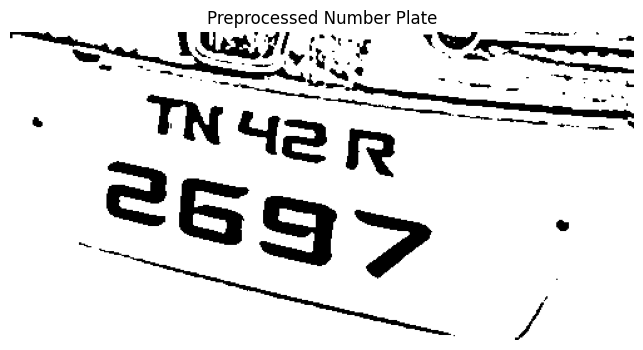

In [11]:
# ============================================
# CELL 11 - OCR ON PREPROCESSED IMAGE
# ============================================

processed_image = preprocess_plate(sample_path)

plt.figure(figsize=(10, 4))

plt.imshow(
    processed_image,
    cmap="gray"
)

plt.axis("off")
plt.title("Preprocessed Number Plate")

plt.show()

In [12]:
# ============================================
# CELL 12 - OCR ON PREPROCESSED IMAGE
# ============================================

processed_results = reader.readtext(
    processed_image
)

print("OCR OUTPUT FROM PREPROCESSED IMAGE:")

for bbox, text, confidence in processed_results:

    print(
        "Text:",
        text,
        "| Confidence:",
        round(confidence, 4)
    )

OCR OUTPUT FROM PREPROCESSED IMAGE:
Text: TN 42R | Confidence: 0.8167
Text: 2697 | Confidence: 0.9506


In [13]:
# ============================================
# CELL 13 - TEXT NORMALIZATION
# ============================================

def clean_plate_text(text):

    text = text.upper()

    # Keep only letters and numbers
    text = re.sub(
        r"[^A-Z0-9]",
        "",
        text
    )

    return text


print(
    "Actual:",
    clean_plate_text(test_labels[sample_name])
)

if processed_results:

    best_text = max(
        processed_results,
        key=lambda x: x[2]
    )[1]

    print(
        "Predicted:",
        clean_plate_text(best_text)
    )

Actual: TN42R2697
Predicted: 2697


In [14]:
# ============================================
# CELL 14 - MULTI-PREPROCESSING
# ============================================

def make_ocr_variants(image_path):

    image = cv2.imread(str(image_path))

    if image is None:
        return []

    # Upscale
    image = cv2.resize(
        image,
        None,
        fx=3,
        fy=3,
        interpolation=cv2.INTER_CUBIC
    )

    gray = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )

    # Variant 1: Original upscaled
    variant_original = image

    # Variant 2: Grayscale
    variant_gray = gray

    # Variant 3: Contrast enhancement
    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    variant_clahe = clahe.apply(gray)

    # Variant 4: Adaptive threshold
    variant_threshold = cv2.adaptiveThreshold(
        variant_clahe,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        31,
        11
    )

    return [
        variant_original,
        variant_gray,
        variant_clahe,
        variant_threshold
    ]


print("OCR preprocessing variants ready.")

OCR preprocessing variants ready.


In [15]:
# ============================================
# CELL 15 - IMPROVED ROBUST OCR PREDICTION
# ============================================

def normalize_ocr_text(text):
    """
    Clean OCR output by keeping only
    uppercase letters and digits.
    """

    if not isinstance(text, str):
        return ""

    text = text.upper().strip()

    text = re.sub(
        r"[^A-Z0-9]",
        "",
        text
    )

    return text


def plate_format_score(text):
    """
    Soft scoring for an Indian vehicle
    registration number.
    """

    if not text:
        return 0

    score = 0

    # Reasonable Indian plate length
    if 6 <= len(text) <= 12:
        score += 2

    # Must contain both letters and digits
    if re.search(r"[A-Z]", text):
        score += 1

    if re.search(r"[0-9]", text):
        score += 1

    # State code normally starts with 2 letters
    if re.match(r"^[A-Z]{2}", text):
        score += 2

    # Common registration structure
    if re.search(r"[A-Z]{2}[0-9]{1,2}", text):
        score += 1

    return score


def bbox_center_x(bbox):
    """
    Return horizontal center of an OCR bounding box.
    """

    return float(
        np.mean(
            [point[0] for point in bbox]
        )
    )


def combine_ocr_results(results):
    """
    Combine multiple OCR detections in
    natural left-to-right reading order.
    """

    if not results:
        return "", 0.0

    valid_results = []

    for bbox, text, confidence in results:

        cleaned = normalize_ocr_text(text)

        if not cleaned:
            continue

        valid_results.append(
            (
                bbox,
                cleaned,
                float(confidence)
            )
        )

    if not valid_results:
        return "", 0.0

    # Sort strictly from left to right
    valid_results.sort(
        key=lambda item:
        bbox_center_x(item[0])
    )

    combined_text = "".join(
        item[1]
        for item in valid_results
    )

    confidence = float(
        np.mean(
            [
                item[2]
                for item in valid_results
            ]
        )
    )

    return combined_text, confidence


def predict_plate_robust(image_path):

    variants = make_ocr_variants(
        image_path
    )

    candidates = []

    for variant_index, variant in enumerate(
        variants
    ):

        try:

            results = reader.readtext(
                variant,
                detail=1,
                paragraph=False,
                allowlist=(
                    "ABCDEFGHIJKLMNOPQRSTUVWXYZ"
                    "0123456789"
                )
            )

        except Exception:
            continue

        if not results:
            continue

        combined_text, confidence = (
            combine_ocr_results(results)
        )

        if not combined_text:
            continue

        # Ignore obviously tiny/noisy outputs
        if len(combined_text) < 4:
            continue

        format_score = plate_format_score(
            combined_text
        )

        # Candidate score
        score = (
            confidence * 2.0
            + format_score * 0.35
        )

        candidates.append(
            {
                "text": combined_text,
                "confidence": confidence,
                "format_score": format_score,
                "variant": variant_index,
                "score": score
            }
        )

    if not candidates:
        return "", 0.0

    # ========================================
    # CONSENSUS BONUS
    # ========================================
    #
    # If multiple preprocessing variants
    # produce exactly the same text, reward it.
    # ========================================

    for candidate in candidates:

        same_count = sum(
            1
            for other in candidates
            if other["text"]
            == candidate["text"]
        )

        candidate["score"] += (
            same_count * 0.75
        )

    # ========================================
    # SORT BEST CANDIDATE
    # ========================================

    candidates.sort(
        key=lambda x: x["score"],
        reverse=True
    )

    best = candidates[0]

    return (
        best["text"],
        float(best["confidence"])
    )


print(
    "Improved robust OCR prediction "
    "function ready."
)

Improved robust OCR prediction function ready.


In [16]:
# ============================================
# CELL 16 - ROBUST OCR TEST
# ============================================

predicted_text, confidence = (
    predict_plate_robust(sample_path)
)

actual_text = normalize_ocr_text(
    test_labels[sample_name]
)

print("========== ROBUST OCR TEST ==========")

print("Actual    :", actual_text)
print("Predicted :", predicted_text)
print("Confidence:", round(confidence, 4))

========== ROBUST OCR TEST ==========
Actual    : TN42R2697
Predicted : TN269742R
Confidence: 0.9915


In [17]:
# ============================================
# CELL 17 - ROBUST OCR EVALUATION
# ============================================

ocr_results_v3 = []

total = len(test_labels)

print("Starting robust OCR evaluation...")
print("Total test images:", total)

for i, (image_name, actual_text) in enumerate(
    test_labels.items(),
    start=1
):

    image_path = TEST_IMG_DIR / image_name

    try:

        predicted_text, confidence = (
            predict_plate_robust(
                image_path
            )
        )

        actual_clean = normalize_ocr_text(
            actual_text
        )

        predicted_clean = normalize_ocr_text(
            predicted_text
        )

        ocr_results_v3.append({
            "image": image_name,
            "actual": actual_clean,
            "predicted": predicted_clean,
            "confidence": confidence
        })

    except Exception as e:

        print(
            "Error:",
            image_name,
            "|",
            e
        )

    if i % 10 == 0 or i == total:

        print(
            f"Processed {i}/{total}"
        )

print("\nEvaluation completed.")

Starting robust OCR evaluation...
Total test images: 254
Processed 10/254
Processed 20/254
Processed 30/254
Processed 40/254
Processed 50/254
Processed 60/254
Processed 70/254
Processed 80/254
Processed 90/254
Processed 100/254
Processed 110/254
Processed 120/254
Processed 130/254
Processed 140/254
Processed 150/254
Processed 160/254
Processed 170/254
Processed 180/254
Processed 190/254
Processed 200/254
Processed 210/254
Processed 220/254
Processed 230/254
Processed 240/254
Processed 250/254
Processed 254/254

Evaluation completed.


In [18]:
# ============================================
# CELL 18 - RESULTS DATAFRAME
# ============================================

results_df = pd.DataFrame(
    ocr_results_v3
)

print(
    "Total results:",
    len(results_df)
)

display(
    results_df.head(20)
)

Total results: 254


,image,actual,predicted,confidence
0,plate_000000.jpg,TN42R2697,TN269742R,0.991511
1,plate_000001.jpg,KL60N5344,KLGON5344,0.542080
2,plate_000002.jpg,TN66U8215,TN66U8215,0.987412
3,plate_000003.jpg,MH01AR5274,IF0AA5274,0.618145
4,plate_000004.jpg,MH02EZ6482,,0.000000
5,plate_000005.jpg,AP02BP2454,AP02BP2454,0.918328
6,plate_000006.jpg,TN21AT0480,TN21AT0480,0.999326
7,plate_000007.jpg,MH02FN2783,,0.000000
8,plate_000008.jpg,MH04JM3383,MH04JM3383,0.936321
9,plate_000009.jpg,TN74F3339,IN7LF3339,0.251266


In [19]:
# ============================================
# CELL 19 - EXACT MATCH ACCURACY
# ============================================

results_df["exact_match"] = (
    results_df["actual"]
    ==
    results_df["predicted"]
)

exact_accuracy_v3 = (
    results_df["exact_match"].mean()
    * 100
)

print(
    f"Exact Plate Recognition Accuracy: "
    f"{exact_accuracy_v3:.2f}%"
)

print(
    "Correct:",
    int(results_df["exact_match"].sum())
)

print(
    "Total:",
    len(results_df)
)

Exact Plate Recognition Accuracy: 27.17%
Correct: 69
Total: 254


In [25]:
# ============================================
# CELL 20 - CHARACTER ACCURACY
# ============================================

def character_accuracy(actual, predicted):
    """
    Character-level accuracy using
    normalized Levenshtein distance.
    """

    actual = normalize_ocr_text(actual)
    predicted = normalize_ocr_text(predicted)

    if not actual:
        return 0.0

    if not predicted:
        return 0.0

    m = len(actual)
    n = len(predicted)

    dp = np.zeros(
        (m + 1, n + 1),
        dtype=int
    )

    for i in range(m + 1):
        dp[i][0] = i

    for j in range(n + 1):
        dp[0][j] = j

    for i in range(1, m + 1):

        for j in range(1, n + 1):

            cost = (
                0
                if actual[i - 1] == predicted[j - 1]
                else 1
            )

            dp[i][j] = min(
                dp[i - 1][j] + 1,
                dp[i][j - 1] + 1,
                dp[i - 1][j - 1] + cost
            )

    edit_distance = dp[m][n]

    accuracy = (
        1 - edit_distance / max(m, n)
    )

    return max(0.0, accuracy)


# Calculate character accuracy
results_df["character_accuracy"] = (
    results_df.apply(
        lambda row: character_accuracy(
            row["actual"],
            row["predicted"]
        ),
        axis=1
    )
)

char_accuracy_v3 = (
    results_df["character_accuracy"].mean()
    * 100
)

print(
    f"Average Character Accuracy: "
    f"{char_accuracy_v3:.2f}%"
)

Average Character Accuracy: 73.55%


In [26]:
# ============================================
# CELL 21 - BEFORE vs CURRENT
# ============================================
print("=" * 60)
print("             OCR IMPROVEMENT")
print("=" * 60)

print(
    "Previous Exact Match      : 17.32%"
)

print(
    f"Current Exact Match       : "
    f"{exact_accuracy_v3:.2f}%"
)

print()

print(
    "Previous Character Accuracy: 64.14%"
)

print(
    f"Current Character Accuracy : "
    f"{char_accuracy_v3:.2f}%"
)

print("=" * 60)

             OCR IMPROVEMENT
Previous Exact Match      : 17.32%
Current Exact Match       : 27.17%

Previous Character Accuracy: 64.14%
Current Character Accuracy : 73.55%


In [27]:
# ============================================
# CELL 22 - WRONG PREDICTIONS
# ============================================

wrong_predictions = results_df[
    results_df["exact_match"] == False
]

print(
    "Wrong predictions:",
    len(wrong_predictions)
)

display(
    wrong_predictions[
        [
            "image",
            "actual",
            "predicted",
            "confidence",
            "character_accuracy"
        ]
    ].head(30)
)

Wrong predictions: 185


,image,actual,predicted,confidence,character_accuracy
0,plate_000000.jpg,TN42R2697,TN269742R,0.991511,0.333333
1,plate_000001.jpg,KL60N5344,KLGON5344,0.542080,0.777778
3,plate_000003.jpg,MH01AR5274,IF0AA5274,0.618145,0.600000
4,plate_000004.jpg,MH02EZ6482,,0.000000,0.000000
7,plate_000007.jpg,MH02FN2783,,0.000000,0.000000
9,plate_000009.jpg,TN74F3339,IN7LF3339,0.251266,0.777778
10,plate_000010.jpg,MH02DQ0196,HIDQO6,0.147951,0.400000
11,plate_000011.jpg,MH02DZ9898,82FKKCZ9898,0.362783,0.454545
13,plate_000013.jpg,HR09G8378,MBODG8328,0.273728,0.444444
14,plate_000014.jpg,HR99BJ6662,HR99BJTEMP6662,0.877617,0.714286


In [28]:
# ============================================
# CELL 23 - WORST OCR RESULTS
# ============================================

display(
    results_df.sort_values(
        by="character_accuracy",
        ascending=True
    ).head(30)
)

,image,actual,predicted,confidence,exact_match,character_accuracy
7,plate_000007.jpg,MH02FN2783,,0.000000,False,0.000000
4,plate_000004.jpg,MH02EZ6482,,0.000000,False,0.000000
55,plate_000055.jpg,HP302165,JOIS,0.466473,False,0.000000
38,plate_000038.jpg,MH02EK4399,,0.000000,False,0.000000
112,plate_000112.jpg,JK13C4452,,0.000000,False,0.000000
179,plate_000179.jpg,MH02CR4364,,0.000000,False,0.000000
235,plate_000235.jpg,AP310U7562,,0.000000,False,0.000000
127,plate_000127.jpg,MH01AV8814,N6S4,0.059529,False,0.100000
239,plate_000239.jpg,MH01BM4824,WOLDITS34,0.018855,False,0.100000
238,plate_000238.jpg,NL02C9593,MA28,0.050750,False,0.111111


In [29]:
# ============================================
# CELL 24 - SAVE ROBUST OCR RESULTS
# ============================================

OUTPUT_DIR = PROJECT_DIR / "outputs"

OUTPUT_DIR.mkdir(
    exist_ok=True
)

output_file = (
    OUTPUT_DIR /
    "ocr_test_results_robust.csv"
)

results_df.to_csv(
    output_file,
    index=False
)

print(
    "Results saved at:"
)

print(output_file)

Results saved at:
C:\Users\lenovo\downloads\ANPR_Traffic_AI\outputs\ocr_test_results_robust.csv


In [30]:
# ============================================
# CELL 25 - FINAL OCR SUMMARY
# ============================================

print("=" * 60)
print("        NUMBER PLATE OCR - FINAL")
print("=" * 60)

print(
    "Test images:",
    len(results_df)
)

print(
    f"Exact Match Accuracy: "
    f"{exact_accuracy_v3:.2f}%"
)

print(
    f"Character Accuracy: "
    f"{char_accuracy_v3:.2f}%"
)

print(
    f"Average Confidence: "
    f"{results_df['confidence'].mean():.4f}"
)

print(
    "Correct:",
    int(results_df["exact_match"].sum())
)

print(
    "Incorrect:",
    int((~results_df["exact_match"]).sum())
)

print("=" * 60)

        NUMBER PLATE OCR - FINAL
Test images: 254
Exact Match Accuracy: 27.17%
Character Accuracy: 73.55%
Average Confidence: 0.6351
Correct: 69
Incorrect: 185
